<a href="https://www.kaggle.com/code/sonawanelalitsunil/lung-cancer-prediction-ai-powered-insights-ml-91?scriptVersionId=226915477" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lung-cancer-prediction-dataset/Lung Cancer Dataset.csv


## Import datasets

In [2]:
df = pd.read_csv('/kaggle/input/lung-cancer-prediction-dataset/Lung Cancer Dataset.csv')

In [3]:
df.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES


In [4]:
df.tail()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
4995,32,0,1,1,0,0,1,60.700696,1,1,1,1,94.012495,0,1,1,0,YES
4996,80,0,1,1,1,1,1,50.751741,0,1,1,1,94.394968,0,0,0,0,YES
4997,51,1,0,0,1,0,0,61.063496,1,0,0,0,98.108901,0,0,0,1,NO
4998,76,1,0,1,0,0,0,48.662872,0,1,0,1,95.577773,1,0,0,0,NO
4999,33,0,1,0,0,1,1,58.245188,0,1,1,1,94.206934,1,0,0,0,NO


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   

In [6]:
df.describe()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE
count,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,0.501200,0.666400,0.6012,0.539800,0.516000,0.439200,55.032043,0.394800,0.80040,0.354200,0.698200,94.991029,0.600600,0.301800,0.204000,0.209600
std,15.799224,0.500049,0.471546,0.4897,0.498463,0.499794,0.496339,7.913083,0.488857,0.39974,0.478318,0.459085,1.481048,0.489824,0.459085,0.403009,0.407064
min,30.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,23.258308,0.000000,0.00000,0.000000,0.000000,89.923133,0.000000,0.000000,0.000000,0.000000
25%,44.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,49.440685,0.000000,1.00000,0.000000,0.000000,93.973176,0.000000,0.000000,0.000000,0.000000
50%,57.000000,1.000000,1.000000,1.0000,1.000000,1.000000,0.000000,55.050421,0.000000,1.00000,0.000000,1.000000,94.974073,1.000000,0.000000,0.000000,0.000000
75%,71.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,60.323320,1.000000,1.00000,1.000000,1.000000,95.989272,1.000000,1.000000,0.000000,0.000000
max,84.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,83.046971,1.000000,1.00000,1.000000,1.000000,99.795786,1.000000,1.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.corr

<bound method DataFrame.corr of       AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0      68       1        1                     1              1   
1      81       1        1                     0              0   
2      58       1        1                     0              0   
3      44       0        1                     0              1   
4      72       0        1                     1              1   
...   ...     ...      ...                   ...            ...   
4995   32       0        1                     1              0   
4996   80       0        1                     1              1   
4997   51       1        0                     0              1   
4998   76       1        0                     1              0   
4999   33       0        1                     0              0   

      EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                         1                  0     57.831178                0   
1

In [10]:
df.dtypes

AGE                         int64
GENDER                      int64
SMOKING                     int64
FINGER_DISCOLORATION        int64
MENTAL_STRESS               int64
EXPOSURE_TO_POLLUTION       int64
LONG_TERM_ILLNESS           int64
ENERGY_LEVEL              float64
IMMUNE_WEAKNESS             int64
BREATHING_ISSUE             int64
ALCOHOL_CONSUMPTION         int64
THROAT_DISCOMFORT           int64
OXYGEN_SATURATION         float64
CHEST_TIGHTNESS             int64
FAMILY_HISTORY              int64
SMOKING_FAMILY_HISTORY      int64
STRESS_IMMUNE               int64
PULMONARY_DISEASE          object
dtype: object

In [11]:
df.columns

Index(['AGE', 'GENDER', 'SMOKING', 'FINGER_DISCOLORATION', 'MENTAL_STRESS',
       'EXPOSURE_TO_POLLUTION', 'LONG_TERM_ILLNESS', 'ENERGY_LEVEL',
       'IMMUNE_WEAKNESS', 'BREATHING_ISSUE', 'ALCOHOL_CONSUMPTION',
       'THROAT_DISCOMFORT', 'OXYGEN_SATURATION', 'CHEST_TIGHTNESS',
       'FAMILY_HISTORY', 'SMOKING_FAMILY_HISTORY', 'STRESS_IMMUNE',
       'PULMONARY_DISEASE'],
      dtype='object')

## Data visualizations

In [12]:
from sklearn.preprocessing import LabelEncoder

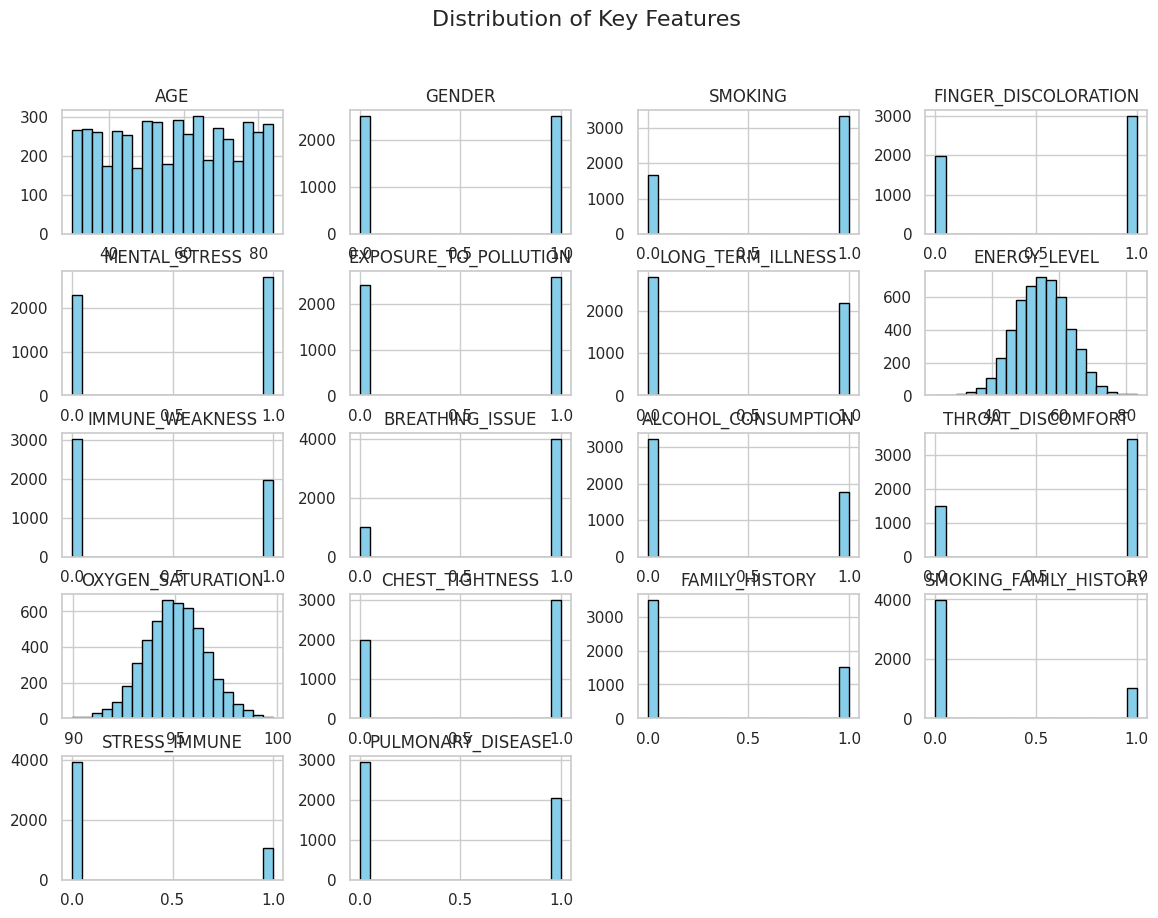

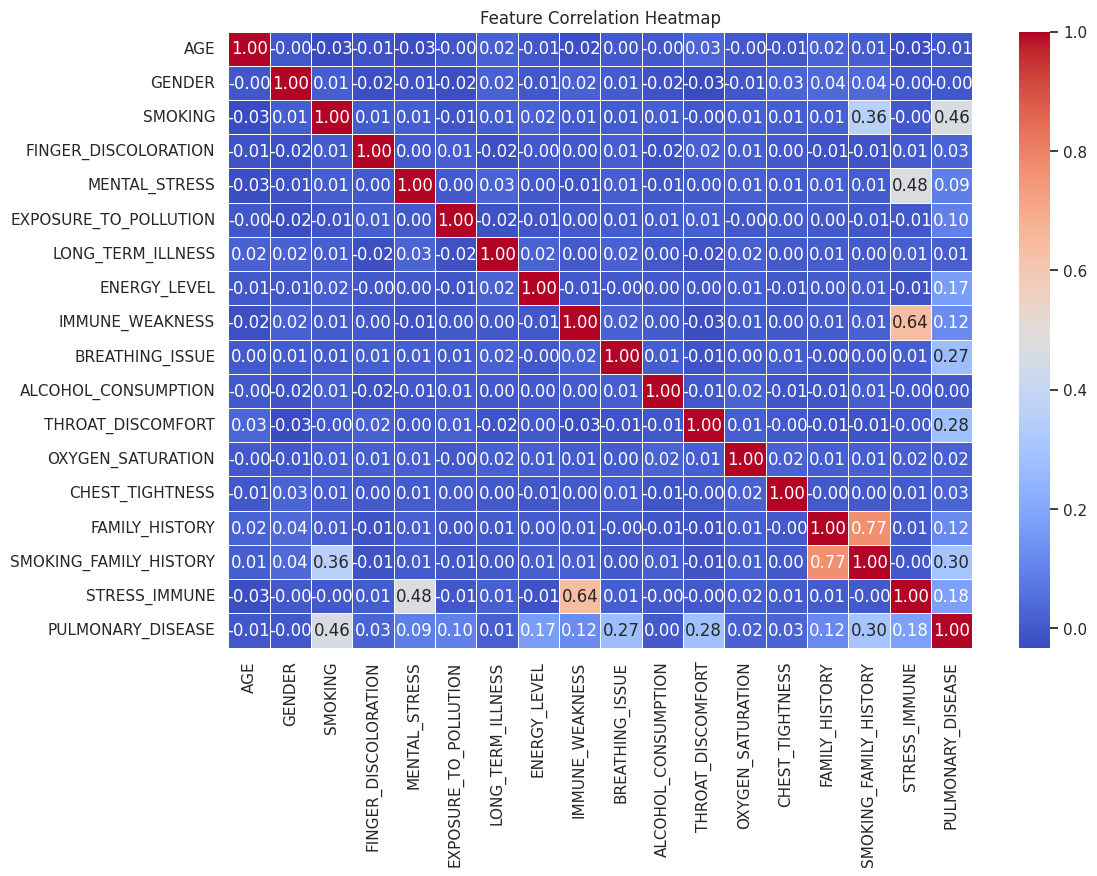

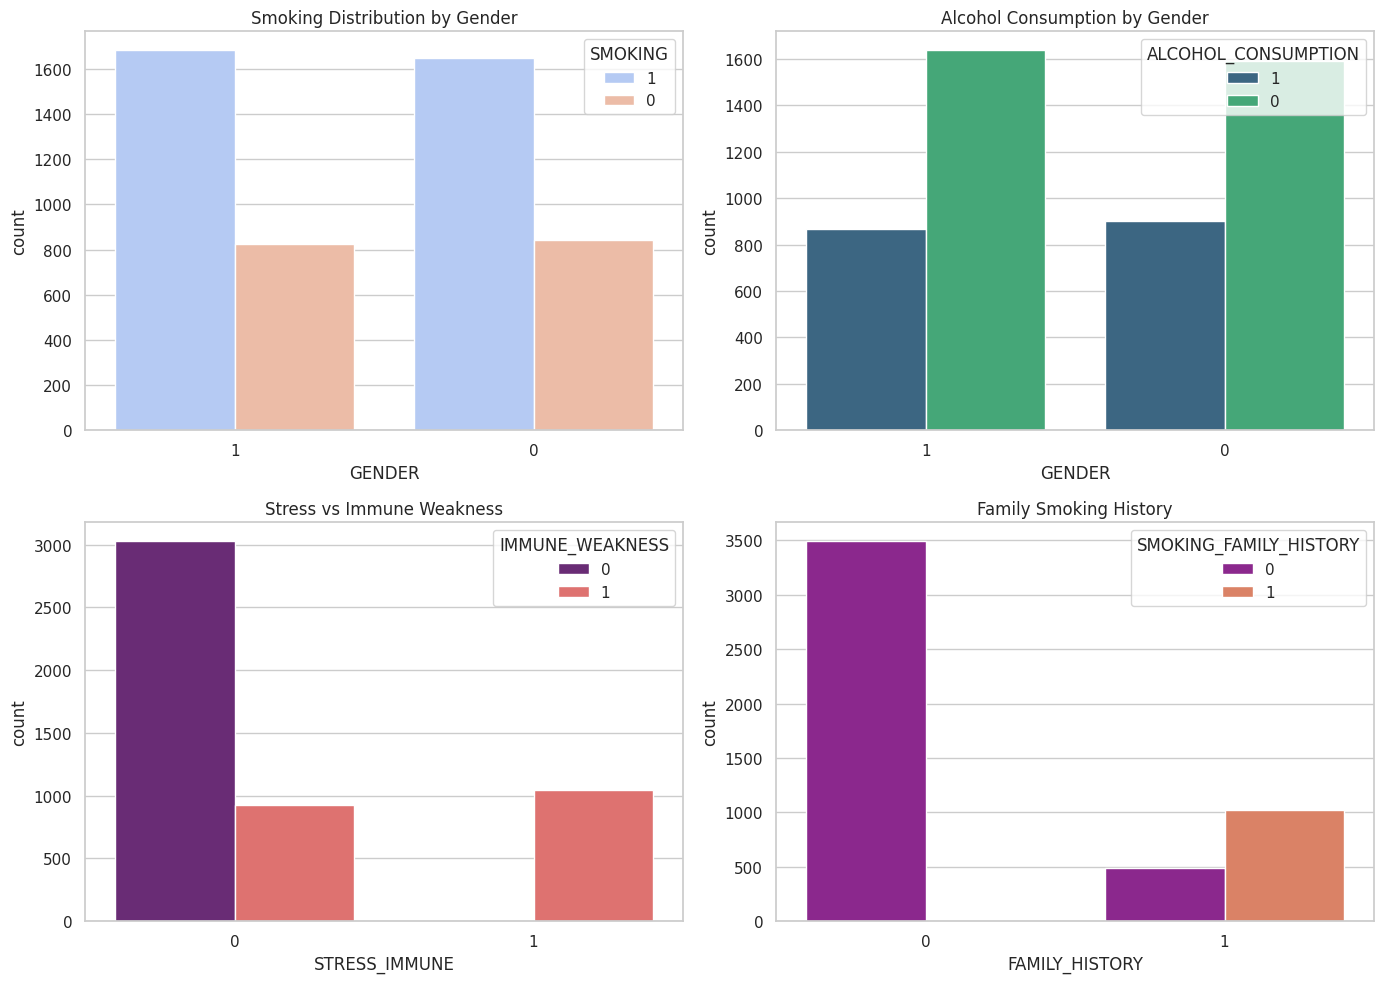

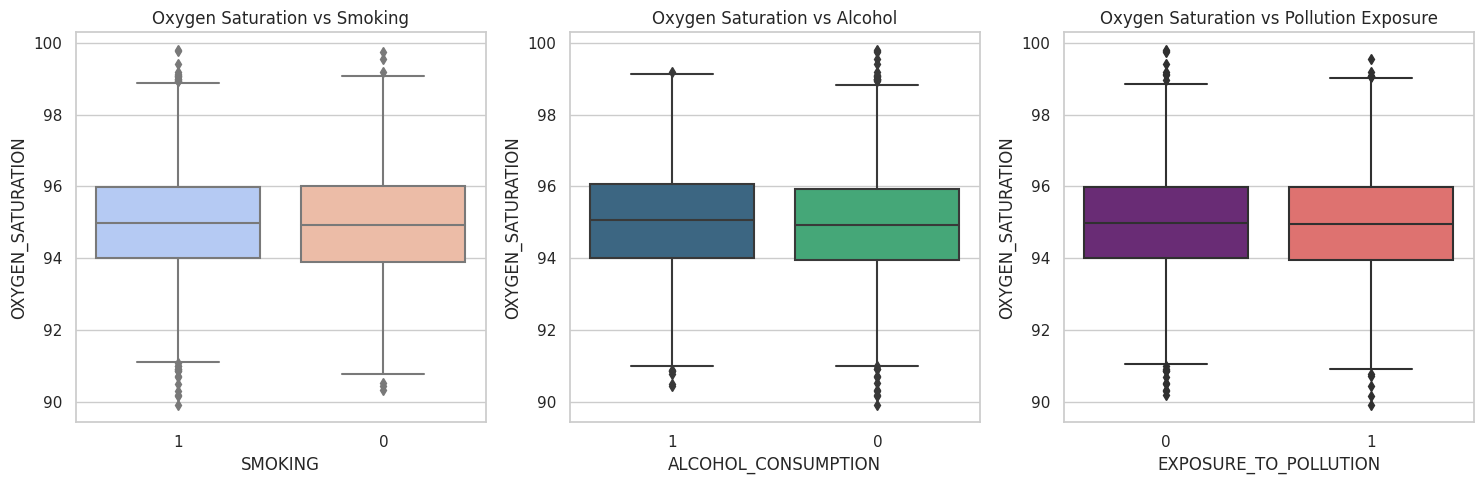

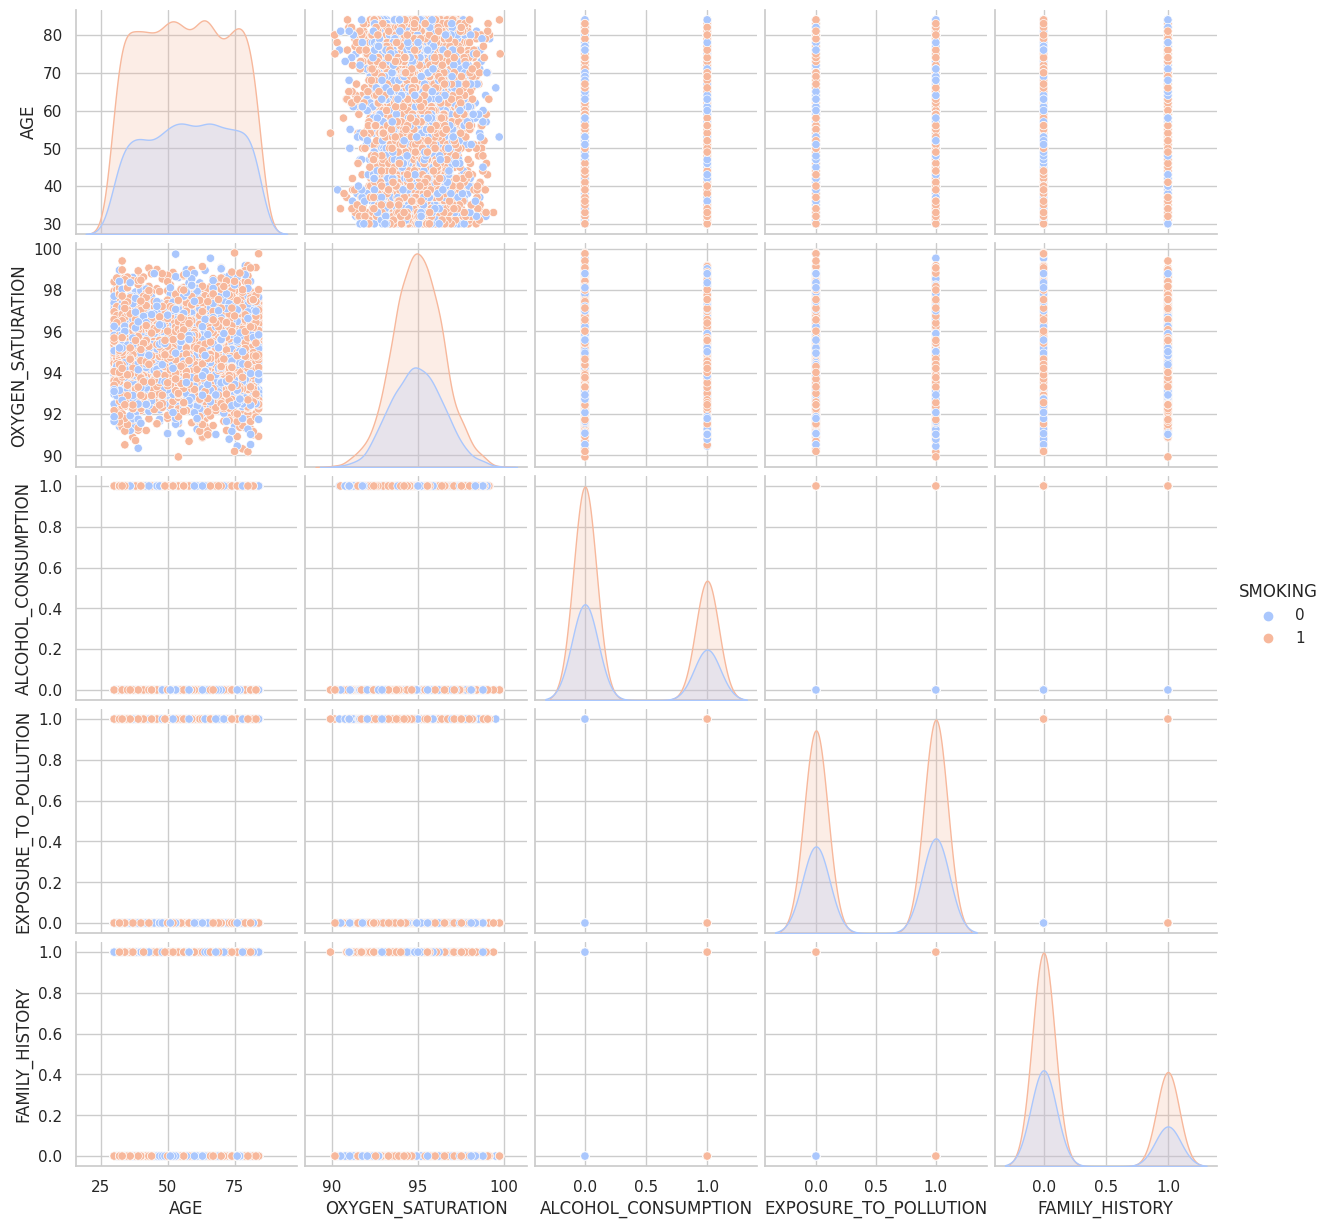

In [13]:
# Encode categorical variables using Label Encoding
df_encoded = df.copy()
label_encoders = {}
for column in df_encoded.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df_encoded[column] = label_encoders[column].fit_transform(df_encoded[column])

# Set Seaborn style
sns.set(style="whitegrid")

# 🔹 1️⃣ Feature Distributions (Numerical Features)
df_encoded.hist(figsize=(14, 10), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Key Features", fontsize=16)
plt.show()

# 🔹 2️⃣ Correlation Heatmap (Using Encoded Data)
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# 🔹 3️⃣ Stacked Bar Charts for Categorical Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ensure categorical variables are strings for proper visualization
df_categorical = df.copy()
for col in ['GENDER', 'SMOKING', 'ALCOHOL_CONSUMPTION', 'STRESS_IMMUNE', 'IMMUNE_WEAKNESS', 
            'FAMILY_HISTORY', 'SMOKING_FAMILY_HISTORY']:
    df_categorical[col] = df_categorical[col].astype(str)

# Smoking vs Gender
sns.countplot(x="GENDER", hue="SMOKING", data=df_categorical, ax=axes[0, 0], palette="coolwarm")
axes[0, 0].set_title("Smoking Distribution by Gender")

# Alcohol vs Gender
sns.countplot(x="GENDER", hue="ALCOHOL_CONSUMPTION", data=df_categorical, ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Alcohol Consumption by Gender")

# Stress vs Immune Weakness
sns.countplot(x="STRESS_IMMUNE", hue="IMMUNE_WEAKNESS", data=df_categorical, ax=axes[1, 0], palette="magma")
axes[1, 0].set_title("Stress vs Immune Weakness")

# Family History vs Smoking Family History
sns.countplot(x="FAMILY_HISTORY", hue="SMOKING_FAMILY_HISTORY", data=df_categorical, ax=axes[1, 1], palette="plasma")
axes[1, 1].set_title("Family Smoking History")

plt.tight_layout()
plt.show()

# 🔹 4️⃣ Boxplots: Effect of Risk Factors on Oxygen Saturation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x="SMOKING", y="OXYGEN_SATURATION", data=df_categorical, ax=axes[0], palette="coolwarm")
axes[0].set_title("Oxygen Saturation vs Smoking")

sns.boxplot(x="ALCOHOL_CONSUMPTION", y="OXYGEN_SATURATION", data=df_categorical, ax=axes[1], palette="viridis")
axes[1].set_title("Oxygen Saturation vs Alcohol")

sns.boxplot(x="EXPOSURE_TO_POLLUTION", y="OXYGEN_SATURATION", data=df_categorical, ax=axes[2], palette="magma")
axes[2].set_title("Oxygen Saturation vs Pollution Exposure")

plt.tight_layout()
plt.show()

# Convert categorical variables to numerical using Label Encoding
df_encoded_pairplot = df.copy()
for column in ['SMOKING', 'ALCOHOL_CONSUMPTION', 'EXPOSURE_TO_POLLUTION', 'FAMILY_HISTORY']:
    df_encoded_pairplot[column] = LabelEncoder().fit_transform(df_encoded_pairplot[column])

# Select only numerical features
selected_features = ["AGE", "OXYGEN_SATURATION", "SMOKING", "ALCOHOL_CONSUMPTION", "EXPOSURE_TO_POLLUTION", "FAMILY_HISTORY"]

# Ensure all selected features are numeric
df_numeric = df_encoded_pairplot[selected_features]

# Pairplot (hue must be categorical)
sns.pairplot(df_numeric, hue="SMOKING", palette="coolwarm")
plt.show()


## Predictive modeling

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

Random Forest Accuracy: 0.9130


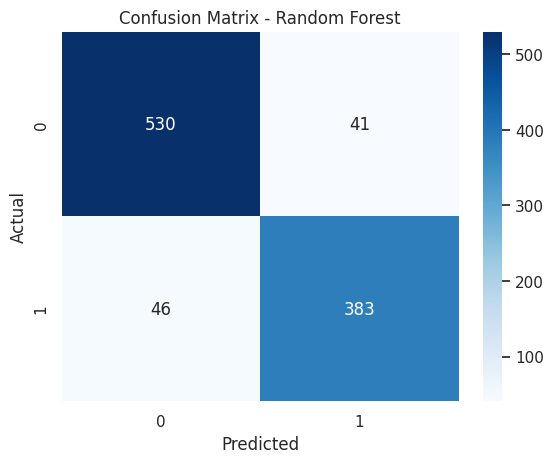

Logistic Regression Accuracy: 0.9110


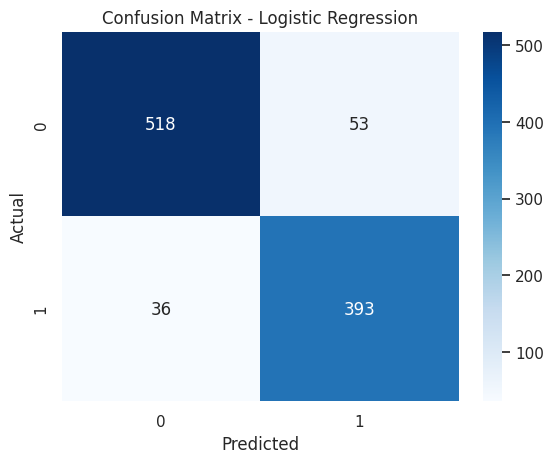

SVM Accuracy: 0.5710


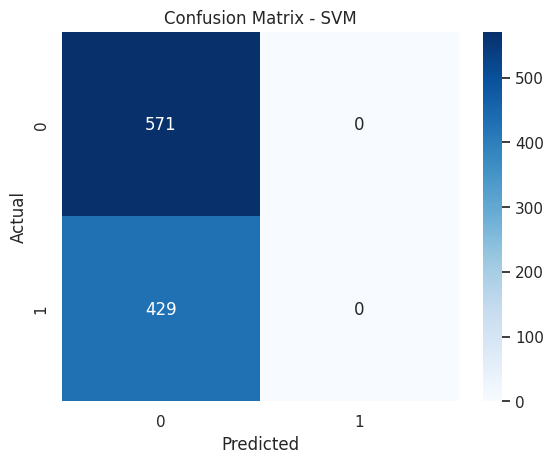

Decision Tree Accuracy: 0.8310


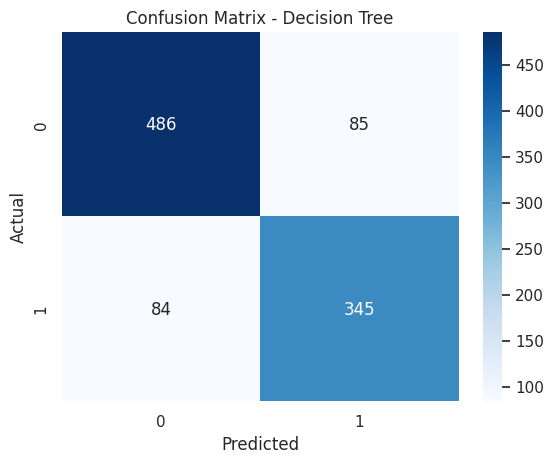

KNN Accuracy: 0.6290


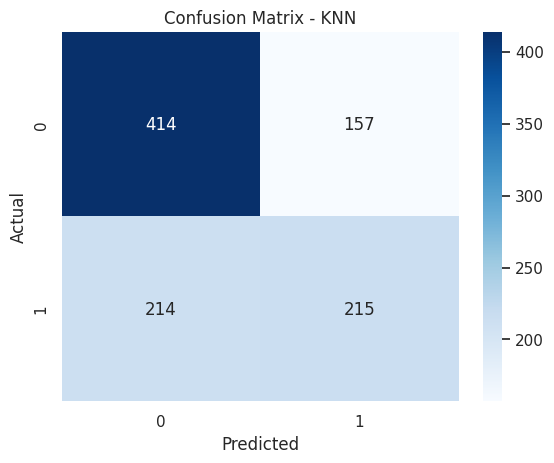

Naive Bayes Accuracy: 0.8750


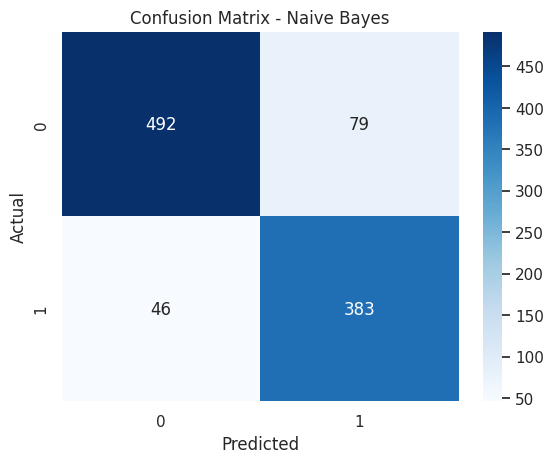

Gradient Boosting Accuracy: 0.9010


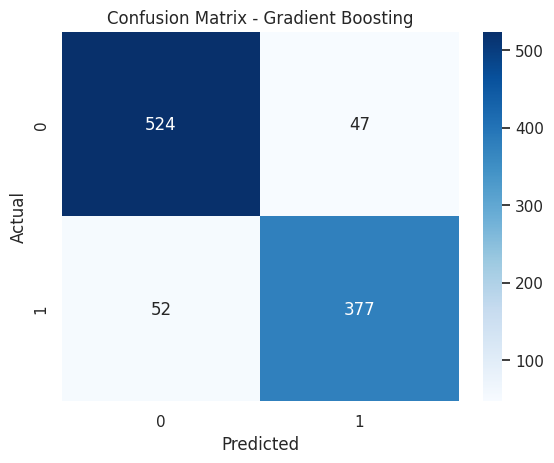

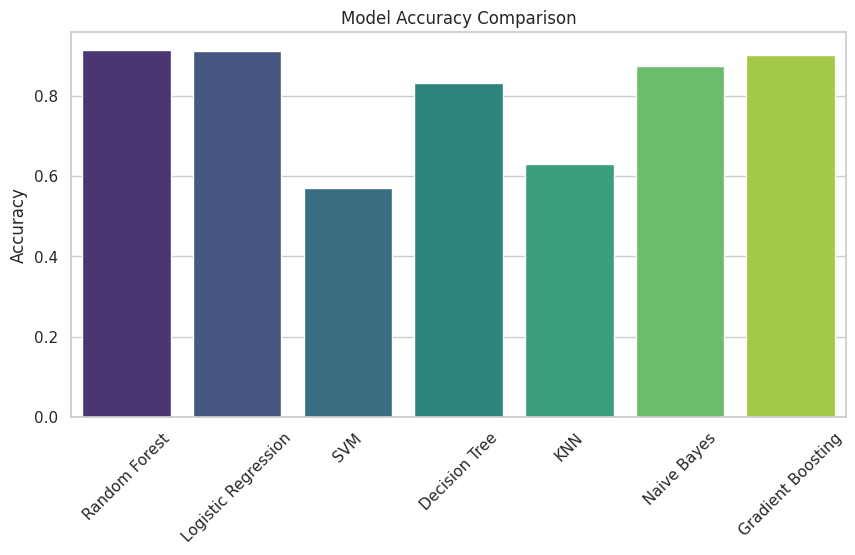

In [15]:
# Encode categorical target variable
le = LabelEncoder()
df['PULMONARY_DISEASE_encoded'] = le.fit_transform(df['PULMONARY_DISEASE'])

# Define features and target
features = df.drop(['PULMONARY_DISEASE', 'PULMONARY_DISEASE_encoded'], axis=1)
target = df['PULMONARY_DISEASE_encoded']

# Encode categorical features
features = features.apply(lambda col: le.fit_transform(col) if col.dtype == 'object' else col)

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Define models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Train and evaluate models
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f'{name} Accuracy: {acc:.4f}')
    
    # Confusion Matrix
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(accuracy_results.keys()), y=list(accuracy_results.values()), palette='viridis')
plt.xticks(rotation=45)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

## Thank you...pls upvote...!!!